<a href="https://colab.research.google.com/github/LoraShima/Exercises_CV_2026/blob/main/CV_Exam_Lora_Shima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Evaluation Exercise: Complete the following exercises**

**Exam Computer Vision 2026 - Lora Shima - IAO**

**1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.**

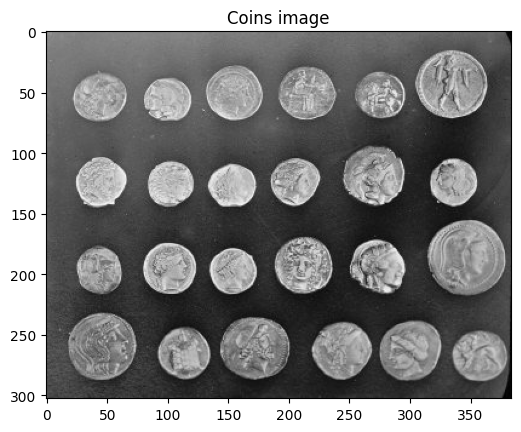

Image size: (303, 384)
Minimum grayscale value: 1
Maximum grayscale value: 252


In [43]:
import matplotlib.pyplot as plt
from skimage import data

image = data.coins()

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title('Coins image')
plt.axis('on')
plt.show()

print("Image size:", image.shape)
print("Minimum grayscale value:", image.min())
print("Maximum grayscale value:", image.max())

**2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.**


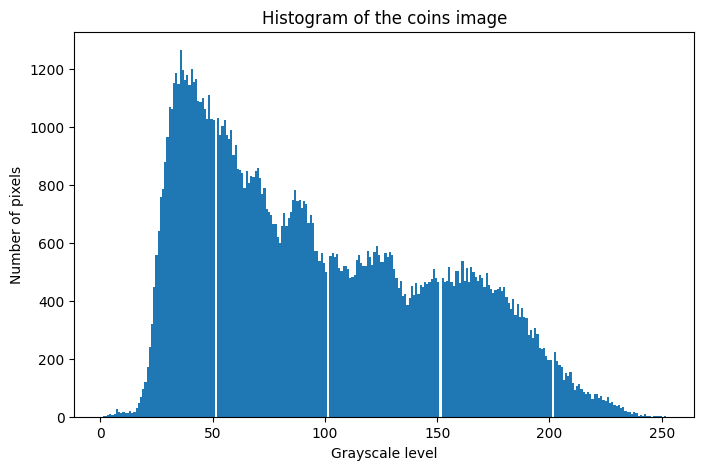

In [44]:
plt.figure(figsize=(8,5))

plt.hist(image.ravel(), bins=256)

plt.title('Histogram of the coins image')
plt.xlabel('Grayscale level')
plt.ylabel('Number of pixels')

plt.show()

The histogram shows how many pixels exist for each grayscale intensity in the image. The large peak at lower grayscale values corresponds mainly to the dark background and shadows between the coins. The middle and higher grayscale values correspond to the coins themselves, since they are brighter than the background. The histogram is spread over many intensity levels because the image contains shadows, reflections, edges, and different lighting conditions on the coins.

**3. Applied noise to the image and use the correct function to erase the noise.**

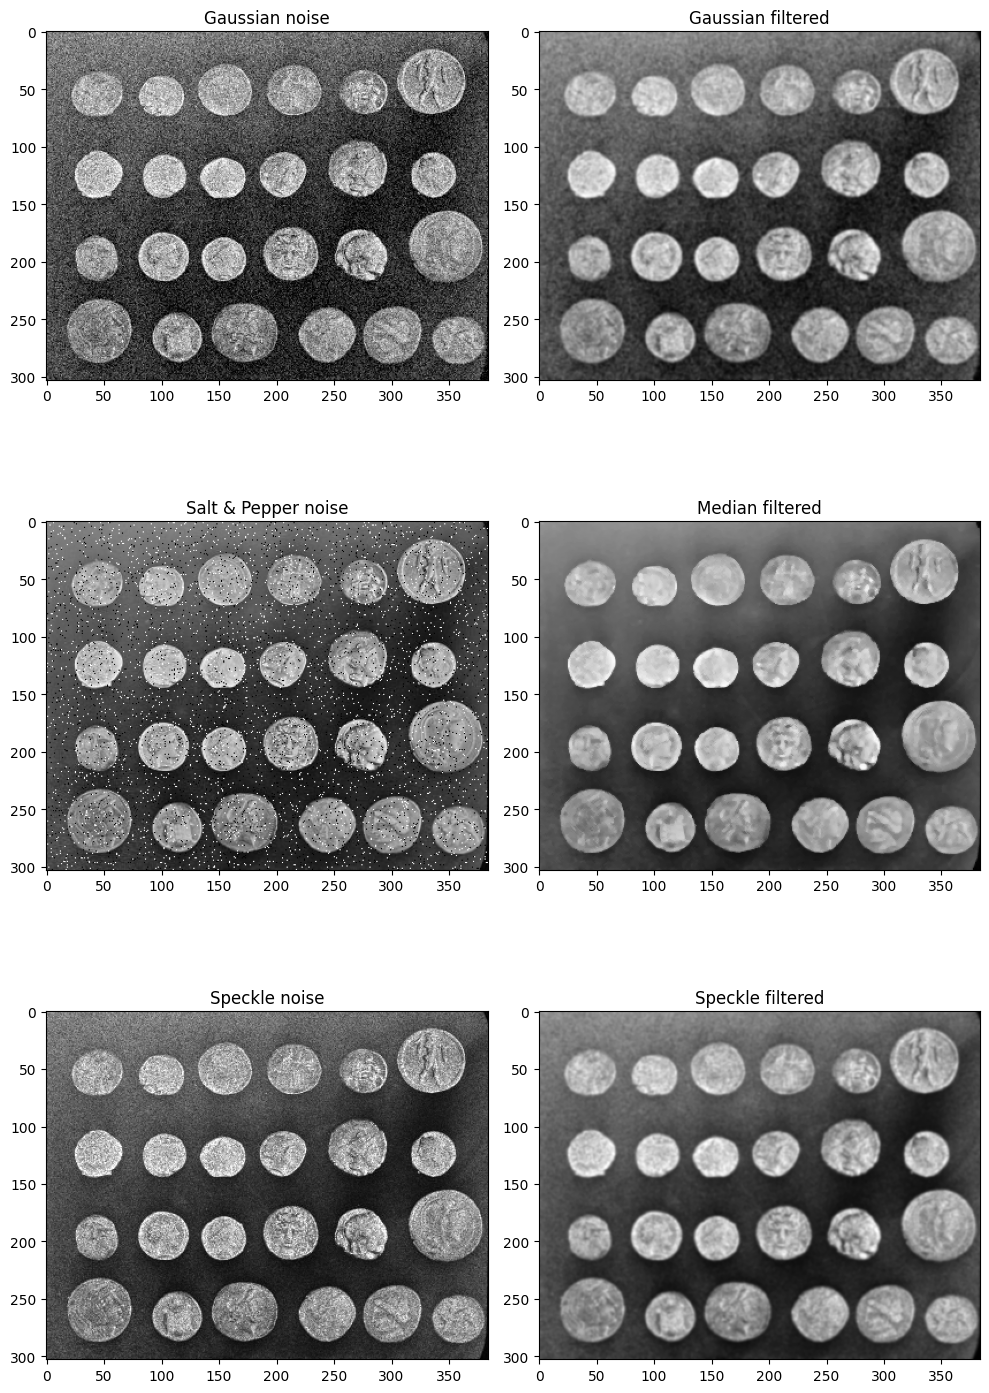

In [45]:
from skimage.util import random_noise
from skimage.filters import gaussian, median
from skimage.morphology import disk

gaussian_noise = random_noise(image, mode='gaussian', var=0.01)
sp_noise = random_noise(image, mode='s&p', amount=0.05)
speckle_noise = random_noise(image, mode='speckle', var=0.02)

gaussian_filtered = gaussian(gaussian_noise, sigma=1)
sp_filtered = median(sp_noise, footprint=disk(2))
speckle_filtered = gaussian(speckle_noise, sigma=1)

fig, ax = plt.subplots(3,2, figsize=(10,15))

titles = ['Gaussian noise', 'Gaussian filtered',
          'Salt & Pepper noise', 'Median filtered',
          'Speckle noise', 'Speckle filtered']

images = [gaussian_noise, gaussian_filtered,
          sp_noise, sp_filtered,
          speckle_noise, speckle_filtered]

for i in range(3):
    ax[i,0].imshow(images[2*i], cmap='gray')
    ax[i,0].set_title(titles[2*i])

    ax[i,1].imshow(images[2*i+1], cmap='gray')
    ax[i,1].set_title(titles[2*i+1])

plt.tight_layout()
plt.show()

Gaussian noise is removed well using a Gaussian filter because the noise is smooth and spread over neighboring pixels. Salt and pepper noise is better removed using a median filter because it eliminates isolated black and white pixels while preserving edges. Speckle noise is also reduced effectively with a Gaussian filter since it behaves like multiplicative random variations over the image.

**4. Segment the image using a k-means clustering algorithm with k=2 and represent the**

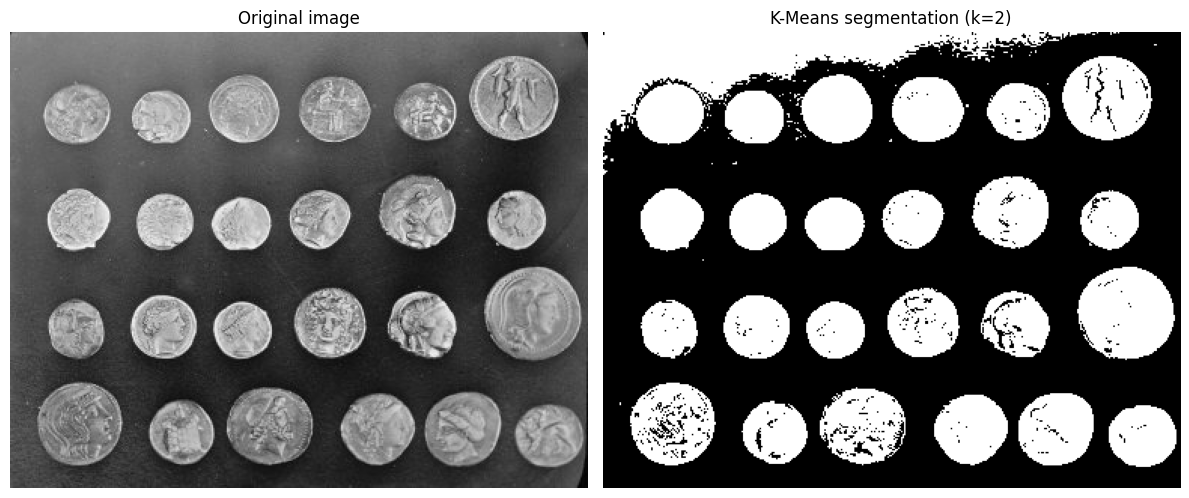

In [46]:
from sklearn.cluster import KMeans

v_image = image.reshape(image.shape[0] * image.shape[1], 1)

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(v_image)

segmented = labels.reshape(image.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

images = [image, segmented]
titles = ['Original image', 'K-Means segmentation (k=2)']

for i in range(2):
    ax[i].imshow(images[i], cmap='gray')
    ax[i].set_title(titles[i])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

**5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?**

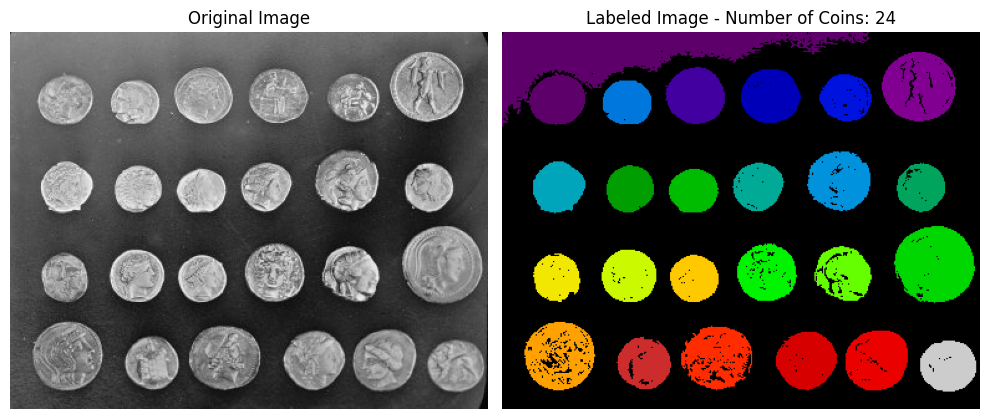

Number of coins in the image: 24


In [47]:
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects

threshold = threshold_otsu(image)
binary_coins = image > threshold

binary_coins_cleaned = remove_small_objects(binary_coins, min_size=100)

labeled_coins, num_coins = label(binary_coins_cleaned, return_num=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(labeled_coins, cmap='nipy_spectral')
axes[1].set_title(f'Labeled Image - Number of Coins: {num_coins}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Number of coins in the image: {num_coins}')

**6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length**

    label    area  axis_major_length  orientation
0       1  8755.0         291.294551    -1.423307
1       2  2459.0          59.966495     1.552547
2       3  1684.0          47.400067     1.330651
3       4  1631.0          47.608317     1.560757
4       5  1193.0          41.310433     1.383445
5       6  1133.0          39.977857     1.446910
6       7  1834.0          51.413541     1.532118
7       8  1325.0          42.451724    -0.883311
8       9  1203.0          40.921169    -1.034534
9      10  1133.0          39.719469    -0.873364
10     11  1129.0          39.179294    -0.923138
11     12  1104.0          39.634983    -1.500398
12     13  3054.0          64.238604     1.321690
13     14  1633.0          48.455200    -1.482099
14     15  1352.0          47.315544     0.943862
15     16  1461.0          44.279748     1.510757
16     17  1095.0          37.726049    -1.098781
17     18  1148.0          39.093268     1.512176
18     19  2099.0          58.230243    -1.108783


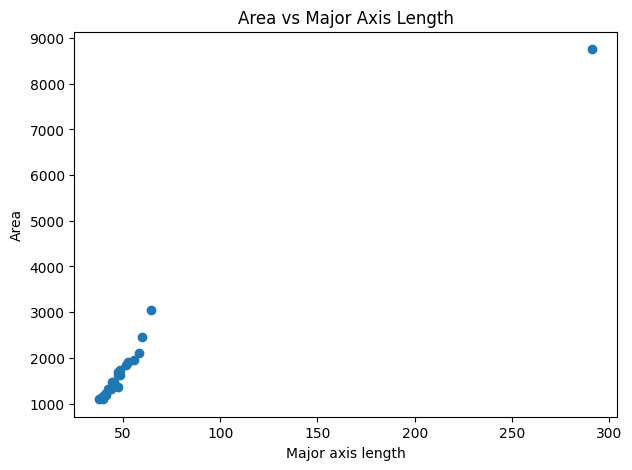

In [48]:
import pandas as pd
from skimage.measure import regionprops_table

properties = regionprops_table(
    labeled_coins,
    properties=['label', 'area', 'axis_major_length', 'orientation']
)

df_coins = pd.DataFrame(properties)
print(df_coins)

average_values = df_coins[['area', 'axis_major_length', 'orientation']].mean()

print("\nAverage area:", average_values['area'])
print("Average major axis length:", average_values['axis_major_length'])
print("Average orientation:", average_values['orientation'])

plt.figure(figsize=(7,5))

plt.scatter(df_coins['axis_major_length'], df_coins['area'])

plt.xlabel('Major axis length')
plt.ylabel('Area')
plt.title('Area vs Major Axis Length')

plt.show()

**7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?**




In [49]:
large_coins = df_coins[df_coins['area'] > 1750]

n_large_coins = len(large_coins)

print(large_coins)
print("\nNumber of coins with area greater than 1750 pixels:", n_large_coins)

    label    area  axis_major_length  orientation
0       1  8755.0         291.294551    -1.423307
1       2  2459.0          59.966495     1.552547
6       7  1834.0          51.413541     1.532118
12     13  3054.0          64.238604     1.321690
18     19  2099.0          58.230243    -1.108783
19     20  1954.0          55.822104    -1.406812
20     21  1918.0          52.847912    -0.985728

Number of coins with area greater than 1750 pixels: 7


**8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).**

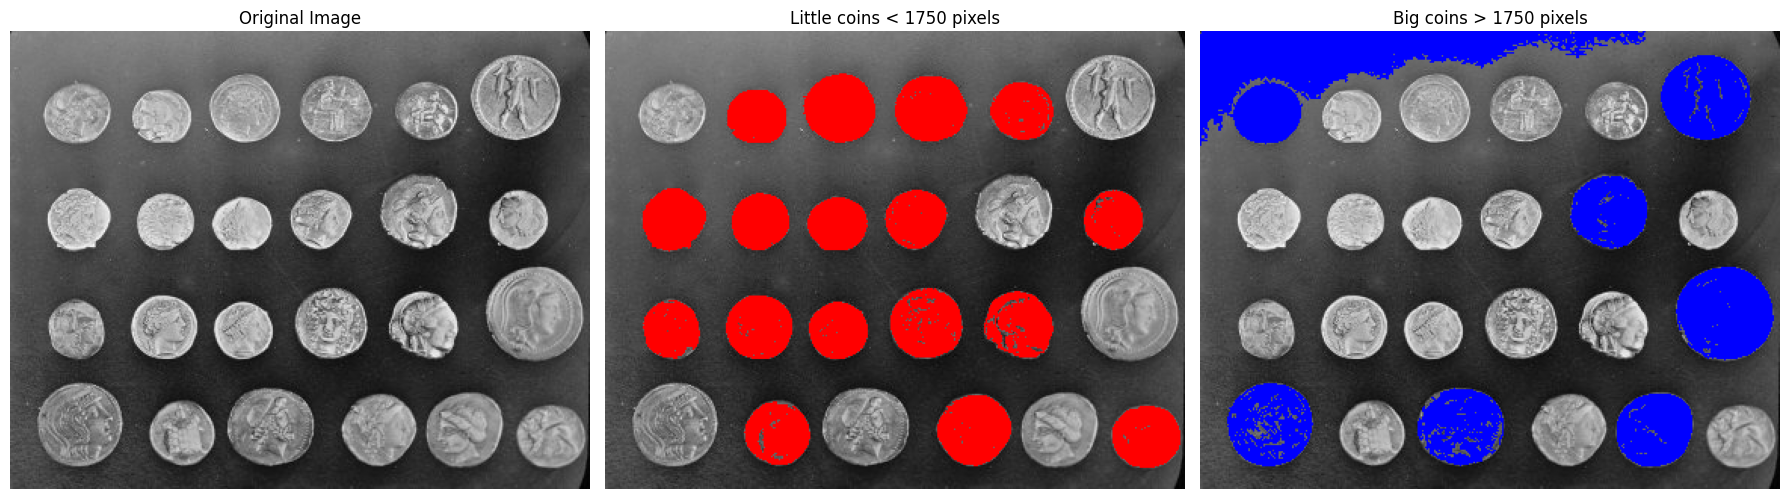

In [50]:
from skimage.color import gray2rgb
import numpy as np

small_coin_labels = df_coins[df_coins["area"] < 1750]["label"].to_numpy()
big_coin_labels = df_coins[df_coins["area"] > 1750]["label"].to_numpy()

small_coin_mask = np.isin(labeled_coins, small_coin_labels)
big_coin_mask = np.isin(labeled_coins, big_coin_labels)

if image.ndim == 2:
    image_rgb = gray2rgb(image)
else:
    image_rgb = image.copy()

if image_rgb.max() > 1:
    image_rgb = image_rgb / 255

small_coins_image = image_rgb.copy()
big_coins_image = image_rgb.copy()

small_coins_image[small_coin_mask] = [1, 0, 0]
big_coins_image[big_coin_mask] = [0, 0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(small_coins_image)
axes[1].set_title("Little coins < 1750 pixels")
axes[1].axis("off")

axes[2].imshow(big_coins_image)
axes[2].set_title("Big coins > 1750 pixels")
axes[2].axis("off")

plt.tight_layout()
plt.show()


**9. Describe the main steps required to perform segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)**

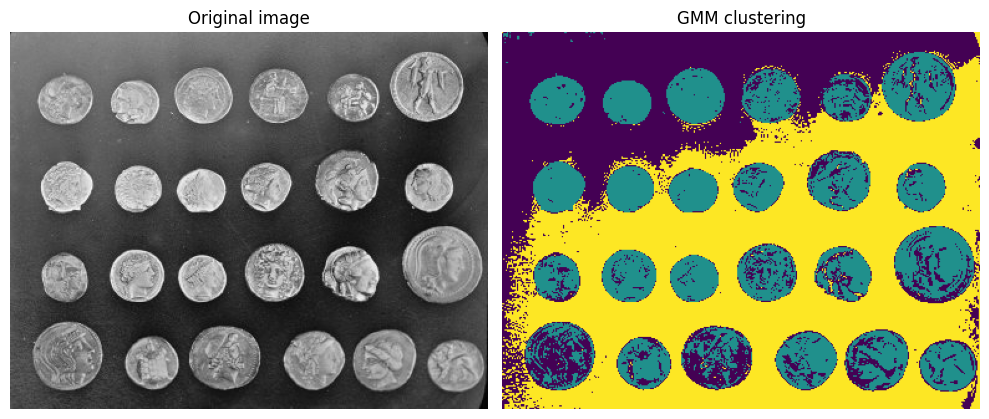

In [52]:
import numpy as np
from sklearn import mixture
import matplotlib.pyplot as plt
from matplotlib import gridspec

# If image is grayscale
if image.ndim == 2:
    v_image = np.reshape(image, (-1, 1))
else:
    v_image = np.reshape(image, (-1, 3))

gmm = mixture.GaussianMixture(n_components=3)
v_gmm = gmm.fit_predict(v_image)

image_gmm = np.reshape(v_gmm, (image.shape[0], image.shape[1]))

fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(2,2)

ax0 = fig.add_subplot(gs[0,0])
ax0.imshow(image, cmap='gray')
ax0.set_title('Original image')
ax0.set_axis_off()

ax1 = fig.add_subplot(gs[0,1])
ax1.imshow(image_gmm)
ax1.set_title('GMM clustering')
ax1.set_axis_off()

plt.tight_layout()
plt.show()

To perform segmentation of an RGB image using an unsupervised clustering algorithm, the image is first reshaped so that each pixel becomes a feature vector containing its RGB values. Then, a clustering algorithm is applied in order to group pixels with similar colors into the same cluster. After clustering, the predicted labels are reshaped back to the original image dimensions to obtain the segmented image.

In this exercise, two unsupervised methods were compared: K-Means and Gaussian Mixture Models (GMM). K-Means separates the image into clusters by assigning each pixel to the nearest cluster center. The result is a clearer binary-like segmentation where the coins are well separated from the background. The regions are more compact and easier to distinguish.

GMM models the image as a mixture of Gaussian distributions and assigns pixels based on probabilities instead of strict distances. In the obtained result, the segmentation is smoother and contains more gradual transitions between regions. However, compared to K-Means, the segmentation is noisier and less clean, especially in the background areas around the coins.

Comparing the results, K-Means produced a cleaner segmentation for this image because the coins and background have relatively distinct grayscale intensities. GMM produced smoother clusters but introduced more noise and irregular regions. Therefore, for this specific image, K-Means gives a more accurate separation of the objects, while GMM provides softer but less precise segmentation boundaries.



**10. Extract the main texture features of this image**

In [42]:
from skimage import data, img_as_ubyte
from skimage.color import rgb2gray
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops

image = data.coins()
image = img_as_ubyte(image)

thresh = threshold_otsu(image)
binary = image > thresh
label_image = label(binary)

props = regionprops(label_image, intensity_image=image)
nregions = len(props)
props_texture = np.zeros((nregions, 5))

for i, p in enumerate(props):
    minr, minc, maxr, maxc = p.bbox
    I = image[minr:maxr, minc:maxc]
    if I.size == 0:
        continue
    g = graycomatrix(
        I,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    contrast = graycoprops(g, 'contrast')[0, 0]
    dissimilarity = graycoprops(g, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(g, 'homogeneity')[0, 0]
    energy = graycoprops(g, 'energy')[0, 0]
    correlation = graycoprops(g, 'correlation')[0, 0]

    props_texture[i, 0] = contrast
    props_texture[i, 1] = dissimilarity
    props_texture[i, 2] = homogeneity
    props_texture[i, 3] = energy
    props_texture[i, 4] = correlation

df = pd.DataFrame(
    props_texture,
    columns=['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation']
)

df.to_excel("coins_texture_features.xlsx", index=False)
print(df.head())


     Contrast  Dissimilarity  Homogeneity    Energy  Correlation
0  254.474130       7.573417     0.310996  0.033827     0.890400
1    7.050000       1.716667     0.551310  0.206828     0.408660
2    2.461538       0.974359     0.642464  0.270145     0.887256
3    0.000000       0.000000     0.000000  0.000000     1.000000
4    0.000000       0.000000     0.000000  0.000000     1.000000


**Personal discussion**

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)

I really enjoyed the Computer Vision course because I am very interested in this field and I found the topics very engaging. During the course, I learned many new concepts related to image processing, segmentation, filtering, texture analysis, clustering, and object detection. I especially liked the practical exercises and projects because they helped me better understand the theory and apply the concepts in real examples using Python and Google Colab.

I also really enjoyed learning about the medical applications of Computer Vision, since it is an area I would like to work in in the future. Seeing how image analysis can be used in healthcare and medical imaging made the course even more interesting for me.

The course increased my interest in Computer Vision even more, and I appreciated the clear explanations, the useful material, and the support during the semester. Thank you very much for your time, effort, and dedication throughout the course!
